<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/06_AngioCAD_UNet128_%EC%8B%9C%EA%B0%81%EA%B2%80%EC%A6%9D_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 5개 모델의 probability 평균
- threshold 0.5
- 16px 미만 연결요소 제거
- Raw와 후처리 결과 모두 표시
- Fold 간 prediction 표준편차로 불확실성 표시



---

표본 구성 </br>

- LEFT / RIGHT
- 정상 / 협착
- 50% 초과 명확한 협착 / 경도 협착
- 짧은 sequence / 긴 sequence
- catheter가 강하게 보이는 영상
- 저대비 영상
- 각 series의 first / middle / last 및 혈관 확률이 가장 높은 frame

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import random
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

PREPROCESSING_DIR = (
    PROJECT_ROOT / "preprocessing_results"
)

SPLIT_DIR = PROJECT_ROOT / "split_results"

UNET128_DIR = (
    PROJECT_ROOT
    / "dca1_results"
    / "unet128_5fold_raw"
)

VISUAL_DIR = (
    PROJECT_ROOT
    / "dca1_results"
    / "unet128_angiocad_visual_validation"
)
VISUAL_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = (
    PREPROCESSING_DIR
    / "03_eligible_frame_manifest.csv"
)

CLINICAL_PATH = (
    PREPROCESSING_DIR
    / "01_clinical_deterministic_clean.csv"
)

SPLIT_PATH = (
    SPLIT_DIR
    / "01_patient_split_candidate_seed42.csv"
)

required_paths = [
    MANIFEST_PATH,
    CLINICAL_PATH,
    SPLIT_PATH,
    UNET128_DIR,
]

for path in required_paths:
    print(
        path.name,
        "exists:",
        path.exists(),
    )

assert all(
    path.exists()
    for path in required_paths
), "필수 저장 파일 또는 폴더가 없습니다."

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Visual output:", VISUAL_DIR)
print("✅ 독립 시각검증 환경 초기화 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
03_eligible_frame_manifest.csv exists: True
01_clinical_deterministic_clean.csv exists: True
01_patient_split_candidate_seed42.csv exists: True
unet128_5fold_raw exists: True
Device: cuda
GPU: Tesla T4
Visual output: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation
✅ 독립 시각검증 환경 초기화 완료


In [ ]:
#@title 01. U-Net128 모델 구조 복원

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=32,
    ):
        super().__init__()

        c = base_channels

        self.enc1 = DoubleConv(in_channels, c)
        self.enc2 = DoubleConv(c, c * 2)
        self.enc3 = DoubleConv(c * 2, c * 4)
        self.enc4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(
            c * 16, c * 8, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(c * 16, c * 8)

        self.up3 = nn.ConvTranspose2d(
            c * 8, c * 4, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(c * 8, c * 4)

        self.up2 = nn.ConvTranspose2d(
            c * 4, c * 2, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(c * 4, c * 2)

        self.up1 = nn.ConvTranspose2d(
            c * 2, c, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(c * 2, c)

        self.output = nn.Conv2d(
            c, out_channels, kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.output(d1)


model_test = UNet()
parameter_count = sum(
    parameter.numel()
    for parameter in model_test.parameters()
)

print("Parameters:", parameter_count)

assert parameter_count == 7_762_465, (
    f"기존 모델과 parameter 수가 다릅니다: "
    f"{parameter_count:,}"
)

test_input = torch.zeros(
    2, 1, 128, 128
)

with torch.no_grad():
    test_output = model_test(test_input)

print("Test output:", test_output.shape)

assert test_output.shape == (2, 1, 128, 128)

del model_test, test_input, test_output

print("✅ U-Net128 모델 구조 복원 완료")

Parameters: 7762465
Test output: torch.Size([2, 1, 128, 128])
✅ U-Net128 모델 구조 복원 완료


In [ ]:
#@title 00-1. AngioCAD multipart RAR 전체 압축 해제 및 원본 Gate

import shutil
import subprocess
import time
from pathlib import Path

RAR_PARTS = [
    PROJECT_ROOT
    / f"AngioCAD_Dataset.part{part}.rar"
    for part in range(1, 5)
]

RAR_PART1 = RAR_PARTS[0]

print("=== Multipart RAR 확인 ===")

for path in RAR_PARTS:
    print(
        path.name,
        "| exists:",
        path.exists(),
        "| size GB:",
        (
            round(path.stat().st_size / 1024**3, 2)
            if path.exists()
            else None
        ),
    )

assert all(
    path.exists()
    for path in RAR_PARTS
), "RAR part1~part4가 모두 필요합니다."

# unrar 준비
if shutil.which("unrar") is None:
    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        ["apt-get", "install", "-y", "unrar"],
        check=True,
    )

print("unrar:", shutil.which("unrar"))

# Colab 임시 디스크 용량 확인
disk_usage = shutil.disk_usage("/content")
free_disk_gb = disk_usage.free / 1024**3

print(
    "압축 해제 전 /content 여유 공간:",
    round(free_disk_gb, 2),
    "GB",
)

assert free_disk_gb >= 30, (
    "압축 해제를 위한 임시 디스크 공간이 "
    "30GB 미만입니다."
)

LOCAL_BASE = Path("/content/AngioCAD")
OLD_VISUAL_EXTRACT = Path(
    "/content/AngioCAD_visual_extract"
)

# 삭제 대상이 정확히 /content 아래인지 확인
safe_delete_targets = [
    LOCAL_BASE,
    OLD_VISUAL_EXTRACT,
]

for target in safe_delete_targets:
    resolved_target = target.resolve()

    assert (
        str(resolved_target).startswith("/content/")
        and resolved_target
        not in {
            Path("/content"),
            Path("/"),
        }
    ), f"안전하지 않은 삭제 경로: {resolved_target}"

    if resolved_target.exists():
        print(
            "기존 임시 추출 폴더 삭제:",
            resolved_target,
        )
        shutil.rmtree(resolved_target)

LOCAL_BASE.mkdir(
    parents=True,
    exist_ok=True,
)

print("\n=== AngioCAD 전체 압축 해제 시작 ===")
print(
    "part1에서 시작하며 part2~part4는 "
    "unrar가 자동으로 연결합니다."
)

start_time = time.time()

extract_result = subprocess.run(
    [
        "unrar",
        "x",
        "-o+",
        "-idq",
        str(RAR_PART1),
        str(LOCAL_BASE) + "/",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    errors="replace",
)

elapsed_minutes = (
    time.time() - start_time
) / 60

print(
    "압축 해제 return code:",
    extract_result.returncode,
)
print(
    "압축 해제 시간:",
    round(elapsed_minutes, 2),
    "분",
)

if extract_result.returncode != 0:
    print(
        extract_result.stdout[-5000:]
    )

assert extract_result.returncode == 0, (
    "AngioCAD multipart RAR 압축 해제에 "
    "실패했습니다."
)

# 실제 AngioCAD_Dataset root 자동 탐색
root_candidates = [
    LOCAL_BASE / "AngioCAD_Dataset",
    LOCAL_BASE,
]

root_candidates.extend(
    path
    for path in LOCAL_BASE.rglob(
        "AngioCAD_Dataset"
    )
    if path.is_dir()
)

root_candidates = list(
    dict.fromkeys(root_candidates)
)


def numeric_patient_count(path):
    if not path.is_dir():
        return 0

    return sum(
        1
        for child in path.iterdir()
        if child.is_dir()
        and child.name.isdigit()
    )


root_scores = [
    (
        numeric_patient_count(path),
        path,
    )
    for path in root_candidates
]

root_scores = sorted(
    root_scores,
    key=lambda item: item[0],
    reverse=True,
)

print("\n=== Dataset root 후보 ===")

for score, path in root_scores[:10]:
    print(
        "patient folders:",
        score,
        "|",
        path,
    )

assert root_scores, (
    "압축 해제 후 dataset root를 "
    "찾지 못했습니다."
)

patient_folder_count, ANGIOCAD_ROOT = (
    root_scores[0]
)

assert patient_folder_count > 0, (
    "숫자 환자 폴더를 찾지 못했습니다."
)

print("\n선택된 ANGIOCAD_ROOT:")
print(ANGIOCAD_ROOT)

# 전체 원본 Gate
patient_directories = sorted(
    [
        path
        for path in ANGIOCAD_ROOT.iterdir()
        if path.is_dir()
        and path.name.isdigit()
    ],
    key=lambda path: int(path.name),
)

series_directory_count = 0
raw_frame_count = 0
patients_with_series = 0

for patient_directory in patient_directories:
    series_directories = [
        path
        for path in patient_directory.iterdir()
        if path.is_dir()
        and path.name.isdigit()
    ]

    if series_directories:
        patients_with_series += 1

    series_directory_count += len(
        series_directories
    )

    for series_directory in series_directories:
        raw_frame_count += sum(
            1
            for path in series_directory.iterdir()
            if path.is_file()
            and path.name.startswith("frame_")
            and path.suffix.lower() == ".png"
        )

print("\n=== AngioCAD 전체 원본 Gate ===")
print(
    "환자 폴더:",
    len(patient_directories),
)
print(
    "실제 series 보유 환자:",
    patients_with_series,
)
print(
    "전체 series 폴더:",
    series_directory_count,
)
print(
    "전체 원본 프레임:",
    raw_frame_count,
)

assert len(patient_directories) == 413, (
    "환자 폴더 수가 기존 감사 결과와 "
    "다릅니다."
)

assert patients_with_series == 412, (
    "실제 series 보유 환자 수가 기존 결과와 "
    "다릅니다."
)

assert series_directory_count == 2711, (
    "전체 series 수가 기존 감사 결과와 "
    "다릅니다."
)

assert raw_frame_count == 121566, (
    "전체 원본 프레임 수가 기존 hash 검사와 "
    "다릅니다."
)

# 이미 04번 셀을 실행했다면 36개 표본 경로 즉시 복구
if "visual_candidate_frame_df" in globals():
    resolved_paths = []

    for _, row in (
        visual_candidate_frame_df.iterrows()
    ):
        frame_path = (
            ANGIOCAD_ROOT
            / str(int(row["patient_id"]))
            / str(int(row["series_id"]))
            / str(row["frame_name"])
        )

        resolved_paths.append(
            str(frame_path)
        )

    visual_candidate_frame_df[
        "resolved_frame_path"
    ] = resolved_paths

    visual_candidate_frame_df[
        "file_exists"
    ] = visual_candidate_frame_df[
        "resolved_frame_path"
    ].map(
        lambda value: Path(value).is_file()
    )

    visual_existing_count = int(
        visual_candidate_frame_df[
            "file_exists"
        ].sum()
    )

    print(
        "\n시각검증 후보 프레임 연결:",
        visual_existing_count,
        "/",
        len(visual_candidate_frame_df),
    )

    assert visual_existing_count == len(
        visual_candidate_frame_df
    )

    FRAME_SAMPLE_PATH = (
        VISUAL_DIR
        / "03_angiocad_visual_candidate_frames.csv"
    )

    visual_candidate_frame_df.to_csv(
        FRAME_SAMPLE_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "시각검증 manifest 갱신:",
        FRAME_SAMPLE_PATH,
    )

print("\n✅ AngioCAD 전체 원본 압축 해제 및 Gate 통과")
print("ANGIOCAD_ROOT =", ANGIOCAD_ROOT)

=== Multipart RAR 확인 ===
AngioCAD_Dataset.part1.rar | exists: True | size GB: 3.91
AngioCAD_Dataset.part2.rar | exists: True | size GB: 3.91
AngioCAD_Dataset.part3.rar | exists: True | size GB: 3.91
AngioCAD_Dataset.part4.rar | exists: True | size GB: 3.56
unrar: /usr/bin/unrar
압축 해제 전 /content 여유 공간: 183.7 GB
기존 임시 추출 폴더 삭제: /content/AngioCAD

=== AngioCAD 전체 압축 해제 시작 ===
part1에서 시작하며 part2~part4는 unrar가 자동으로 연결합니다.
압축 해제 return code: 0
압축 해제 시간: 6.7 분

=== Dataset root 후보 ===
patient folders: 413 | /content/AngioCAD/AngioCAD_Dataset
patient folders: 0 | /content/AngioCAD

선택된 ANGIOCAD_ROOT:
/content/AngioCAD/AngioCAD_Dataset

=== AngioCAD 전체 원본 Gate ===
환자 폴더: 413
실제 series 보유 환자: 412
전체 series 폴더: 2711
전체 원본 프레임: 121566

시각검증 후보 프레임 연결: 36 / 36
시각검증 manifest 갱신: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/03_angiocad_visual_candidate_frames.csv

✅ AngioCAD 전체 원본 압축 해제 및 Gate 통과
ANGIOCAD_ROOT = /content/AngioCAD/Ang

In [ ]:
#@title 5개 Fold의 best validation-loss checkpoint를 자동 탐색하고 호환성을 검사

#@title 02. U-Net128 5-Fold checkpoint 자동 탐색 및 로드

import re
from collections import defaultdict

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"지원하지 않는 checkpoint 형식: "
            f"{type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "net",
        "weights",
    ]

    for key in candidate_keys:
        value = checkpoint.get(key)

        if isinstance(value, dict):
            return value

        if isinstance(value, nn.Module):
            return value.state_dict()

    # checkpoint 자체가 state_dict인 경우
    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        return checkpoint

    raise KeyError(
        f"state_dict를 찾지 못했습니다. "
        f"keys={list(checkpoint.keys())}"
    )


def clean_state_dict_keys(state_dict):
    cleaned = {}

    for key, value in state_dict.items():
        new_key = key

        for prefix in ["module.", "model.", "net."]:
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]

        cleaned[new_key] = value

    return cleaned


def load_compatible_state(model, saved_state):
    saved_state = clean_state_dict_keys(saved_state)
    current_state = model.state_dict()

    # 1순위: 이름까지 정확히 일치
    try:
        model.load_state_dict(
            saved_state,
            strict=True,
        )
        return "STRICT_NAME_MATCH"

    except RuntimeError:
        pass

    # 2순위: 등록 순서와 tensor shape가 완전히 같은 경우
    saved_items = list(saved_state.items())
    current_items = list(current_state.items())

    if len(saved_items) != len(current_items):
        raise RuntimeError(
            f"state 항목 수 불일치: "
            f"saved={len(saved_items)}, "
            f"current={len(current_items)}"
        )

    shape_mismatches = []

    for index, (
        (saved_key, saved_tensor),
        (current_key, current_tensor),
    ) in enumerate(zip(saved_items, current_items)):

        if saved_tensor.shape != current_tensor.shape:
            shape_mismatches.append({
                "index": index,
                "saved_key": saved_key,
                "saved_shape": tuple(saved_tensor.shape),
                "current_key": current_key,
                "current_shape": tuple(current_tensor.shape),
            })

    if shape_mismatches:
        raise RuntimeError(
            "tensor 순서/shape가 일치하지 않습니다.\n"
            f"첫 불일치: {shape_mismatches[0]}"
        )

    remapped_state = {
        current_key: saved_tensor
        for (
            (_, saved_tensor),
            (current_key, _),
        ) in zip(saved_items, current_items)
    }

    model.load_state_dict(
        remapped_state,
        strict=True,
    )

    return "ORDER_AND_SHAPE_REMAP"


def get_checkpoint_metadata(checkpoint, path):
    path_text = str(path).lower()

    fold = None

    if isinstance(checkpoint, dict):
        for key in ["fold", "cv_fold", "fold_index"]:
            if key in checkpoint:
                try:
                    fold = int(checkpoint[key])
                    break
                except Exception:
                    pass

    if fold is None:
        match = re.search(
            r"fold[_\-\s]?([0-4])",
            path_text,
        )

        if match:
            fold = int(match.group(1))

    epoch = None

    if isinstance(checkpoint, dict):
        for key in [
            "epoch",
            "checkpoint_epoch",
            "best_epoch",
            "best_loss_epoch",
        ]:
            if key in checkpoint:
                try:
                    epoch = int(checkpoint[key])
                    break
                except Exception:
                    pass

    return fold, epoch


all_checkpoint_paths = sorted(
    UNET128_DIR.rglob("*.pt")
)

print("발견된 전체 .pt:", len(all_checkpoint_paths))

assert all_checkpoint_paths, (
    f"checkpoint가 없습니다: {UNET128_DIR}"
)

checkpoint_candidates = defaultdict(list)

for path in all_checkpoint_paths:
    path_text = str(path).lower()

    # best validation loss를 최우선으로 선택
    score = 0

    if "best_validation_loss" in path_text:
        score += 100
    elif "best" in path_text and "loss" in path_text:
        score += 80
    elif "best" in path_text:
        score += 50

    if "dice" in path_text:
        score -= 20

    if "resume" in path_text:
        score -= 100

    if "tiny" in path_text:
        score -= 100

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    fold, epoch = get_checkpoint_metadata(
        checkpoint,
        path,
    )

    if fold is not None:
        checkpoint_candidates[fold].append({
            "path": path,
            "score": score,
            "epoch": epoch,
            "checkpoint": checkpoint,
        })


print("\n=== Fold별 checkpoint 후보 ===")

for fold in range(5):
    candidates = sorted(
        checkpoint_candidates.get(fold, []),
        key=lambda item: (
            item["score"],
            str(item["path"]),
        ),
        reverse=True,
    )

    print(f"\nFold {fold}: {len(candidates)}개")

    for item in candidates[:5]:
        print(
            f"  score={item['score']:>4}",
            f"epoch={item['epoch']}",
            item["path"].relative_to(UNET128_DIR),
        )

assert all(
    len(checkpoint_candidates.get(fold, [])) > 0
    for fold in range(5)
), "일부 Fold의 checkpoint를 찾지 못했습니다."


unet128_ensemble = []
checkpoint_audit_rows = []

for fold in range(5):
    candidates = sorted(
        checkpoint_candidates[fold],
        key=lambda item: (
            item["score"],
            str(item["path"]),
        ),
        reverse=True,
    )

    loaded = False
    load_errors = []

    for item in candidates:
        try:
            model = UNet(
                in_channels=1,
                out_channels=1,
                base_channels=32,
            )

            state_dict = extract_state_dict(
                item["checkpoint"]
            )

            load_method = load_compatible_state(
                model,
                state_dict,
            )

            model = model.to(DEVICE)
            model.eval()

            # forward 안전성 확인
            with torch.no_grad():
                test_logits = model(
                    torch.zeros(
                        1, 1, 128, 128,
                        device=DEVICE,
                    )
                )

            assert test_logits.shape == (
                1, 1, 128, 128
            )

            assert torch.isfinite(
                test_logits
            ).all()

            unet128_ensemble.append(model)

            checkpoint_audit_rows.append({
                "fold": fold,
                "epoch": item["epoch"],
                "checkpoint_path": str(item["path"]),
                "candidate_score": item["score"],
                "load_method": load_method,
                "parameter_count": sum(
                    parameter.numel()
                    for parameter in model.parameters()
                ),
                "finite_output": True,
                "status": "PASS",
            })

            print(
                f"✅ Fold {fold}:",
                item["path"].name,
                "| epoch:",
                item["epoch"],
                "|",
                load_method,
            )

            loaded = True
            break

        except Exception as error:
            load_errors.append(
                f"{item['path'].name}: {error}"
            )

    if not loaded:
        raise RuntimeError(
            f"Fold {fold} 로드 실패:\n"
            + "\n".join(load_errors)
        )


checkpoint_audit_df = pd.DataFrame(
    checkpoint_audit_rows
)

display(checkpoint_audit_df)

assert len(unet128_ensemble) == 5
assert checkpoint_audit_df["status"].eq("PASS").all()
assert checkpoint_audit_df["fold"].nunique() == 5
assert checkpoint_audit_df[
    "parameter_count"
].eq(7_762_465).all()

CHECKPOINT_AUDIT_PATH = (
    VISUAL_DIR
    / "00_unet128_ensemble_checkpoint_audit.csv"
)

checkpoint_audit_df.to_csv(
    CHECKPOINT_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ U-Net128 5-Fold ensemble 로드 완료")
print("Ensemble models:", len(unet128_ensemble))
print("저장:", CHECKPOINT_AUDIT_PATH)

발견된 전체 .pt: 10

=== Fold별 checkpoint 후보 ===

Fold 0: 2개
  score=  50 epoch=100 fold_0/fold_0_best.pt
  score=   0 epoch=100 fold_0/fold_0_last.pt

Fold 1: 2개
  score=  50 epoch=100 fold_1/fold_1_best.pt
  score=   0 epoch=100 fold_1/fold_1_last.pt

Fold 2: 2개
  score=  50 epoch=83 fold_2/fold_2_best.pt
  score=   0 epoch=98 fold_2/fold_2_last.pt

Fold 3: 2개
  score=  50 epoch=96 fold_3/fold_3_best.pt
  score=   0 epoch=100 fold_3/fold_3_last.pt

Fold 4: 2개
  score=  50 epoch=99 fold_4/fold_4_best.pt
  score=   0 epoch=100 fold_4/fold_4_last.pt
✅ Fold 0: fold_0_best.pt | epoch: 100 | ORDER_AND_SHAPE_REMAP
✅ Fold 1: fold_1_best.pt | epoch: 100 | ORDER_AND_SHAPE_REMAP
✅ Fold 2: fold_2_best.pt | epoch: 83 | ORDER_AND_SHAPE_REMAP
✅ Fold 3: fold_3_best.pt | epoch: 96 | ORDER_AND_SHAPE_REMAP
✅ Fold 4: fold_4_best.pt | epoch: 99 | ORDER_AND_SHAPE_REMAP


,fold,epoch,checkpoint_path,candidate_score,load_method,parameter_count,finite_output,status
0,0,100,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,50,ORDER_AND_SHAPE_REMAP,7762465,True,PASS
1,1,100,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,50,ORDER_AND_SHAPE_REMAP,7762465,True,PASS
2,2,83,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,50,ORDER_AND_SHAPE_REMAP,7762465,True,PASS
3,3,96,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,50,ORDER_AND_SHAPE_REMAP,7762465,True,PASS
4,4,99,/content/drive/MyDrive/[MacGyver]최종프로젝ᄐ...,50,ORDER_AND_SHAPE_REMAP,7762465,True,PASS



✅ U-Net128 5-Fold ensemble 로드 완료
Ensemble models: 5
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/00_unet128_ensemble_checkpoint_audit.csv


In [ ]:
#@title 03. Checkpoint remap 재현성 검증 — 저장된 OOF와 비교

OOF_PATH = (
    UNET128_DIR
    / "05_unet128_oof_predictions.npz"
)

assert OOF_PATH.exists(), f"OOF 파일 없음: {OOF_PATH}"

oof_data = np.load(
    OOF_PATH,
    allow_pickle=False,
)

required_keys = [
    "images_uint8",
    "probabilities_float16",
    "cv_folds",
]

for key in required_keys:
    assert key in oof_data.files, (
        f"OOF key 없음: {key}"
    )

oof_images = oof_data["images_uint8"]
saved_probabilities = (
    oof_data["probabilities_float16"]
    .astype(np.float32)
)
oof_folds = oof_data["cv_folds"].astype(int)

print("OOF images:", oof_images.shape)
print("Saved probabilities:", saved_probabilities.shape)
print("OOF folds:", np.unique(oof_folds))

reproduced_probabilities = np.zeros_like(
    saved_probabilities,
    dtype=np.float32,
)

BATCH_SIZE = 16

for fold, model in enumerate(unet128_ensemble):
    fold_indices = np.flatnonzero(
        oof_folds == fold
    )

    for start in range(
        0,
        len(fold_indices),
        BATCH_SIZE,
    ):
        batch_indices = fold_indices[
            start:start + BATCH_SIZE
        ]

        batch_images = torch.from_numpy(
            oof_images[batch_indices]
            .astype(np.float32)
            / 255.0
        )

        if batch_images.ndim == 3:
            batch_images = batch_images[:, None, :, :]

        batch_images = batch_images.to(DEVICE)

        with torch.no_grad():
            batch_probability = torch.sigmoid(
                model(batch_images)
            )

        reproduced_probabilities[
            batch_indices
        ] = (
            batch_probability[:, 0]
            .detach()
            .cpu()
            .numpy()
        )

absolute_error = np.abs(
    reproduced_probabilities
    - saved_probabilities
)

saved_masks = (
    saved_probabilities >= 0.5
)

reproduced_masks = (
    reproduced_probabilities >= 0.5
)

audit_rows = []

for fold in range(5):
    fold_mask = oof_folds == fold
    fold_error = absolute_error[fold_mask]

    mask_agreement = np.mean(
        saved_masks[fold_mask]
        == reproduced_masks[fold_mask]
    )

    audit_rows.append({
        "fold": fold,
        "sample_count": int(fold_mask.sum()),
        "mean_absolute_error": float(
            fold_error.mean()
        ),
        "max_absolute_error": float(
            fold_error.max()
        ),
        "threshold_mask_agreement": float(
            mask_agreement
        ),
    })

remap_reproduction_df = pd.DataFrame(
    audit_rows
)

remap_reproduction_df["status"] = np.where(
    (
        remap_reproduction_df[
            "mean_absolute_error"
        ].le(1e-3)
        &
        remap_reproduction_df[
            "max_absolute_error"
        ].le(1e-2)
        &
        remap_reproduction_df[
            "threshold_mask_agreement"
        ].ge(0.999)
    ),
    "PASS",
    "FAIL",
)

display(remap_reproduction_df)

print(
    "전체 평균 절대 오차:",
    float(absolute_error.mean()),
)
print(
    "전체 최대 절대 오차:",
    float(absolute_error.max()),
)
print(
    "전체 threshold mask 일치율:",
    float(
        np.mean(
            saved_masks
            == reproduced_masks
        )
    ),
)

assert remap_reproduction_df[
    "status"
].eq("PASS").all(), (
    "Checkpoint remap 결과가 저장된 OOF 예측과 "
    "일치하지 않습니다."
)

REMAP_AUDIT_PATH = (
    VISUAL_DIR
    / "01_unet128_checkpoint_remap_reproduction.csv"
)

remap_reproduction_df.to_csv(
    REMAP_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("✅ Checkpoint remap 재현성 Gate 통과")
print("저장:", REMAP_AUDIT_PATH)

OOF images: (134, 128, 128)
Saved probabilities: (134, 128, 128)
OOF folds: [0 1 2 3 4]


,fold,sample_count,mean_absolute_error,max_absolute_error,threshold_mask_agreement,status
0,0,27,0.000026,0.000260,0.999998,PASS
1,1,27,0.000024,0.000255,1.000000,PASS
2,2,27,0.000018,0.000264,0.999995,PASS
3,3,27,0.000025,0.000255,0.999995,PASS
4,4,26,0.000026,0.000255,0.999995,PASS


전체 평균 절대 오차: 2.365688305872027e-05
전체 최대 절대 오차: 0.00026416778564453125
전체 threshold mask 일치율: 0.9999968115963153
✅ Checkpoint remap 재현성 Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/01_unet128_checkpoint_remap_reproduction.csv


시각검증 series: 12
후보 프레임: 36
실제 존재: 36


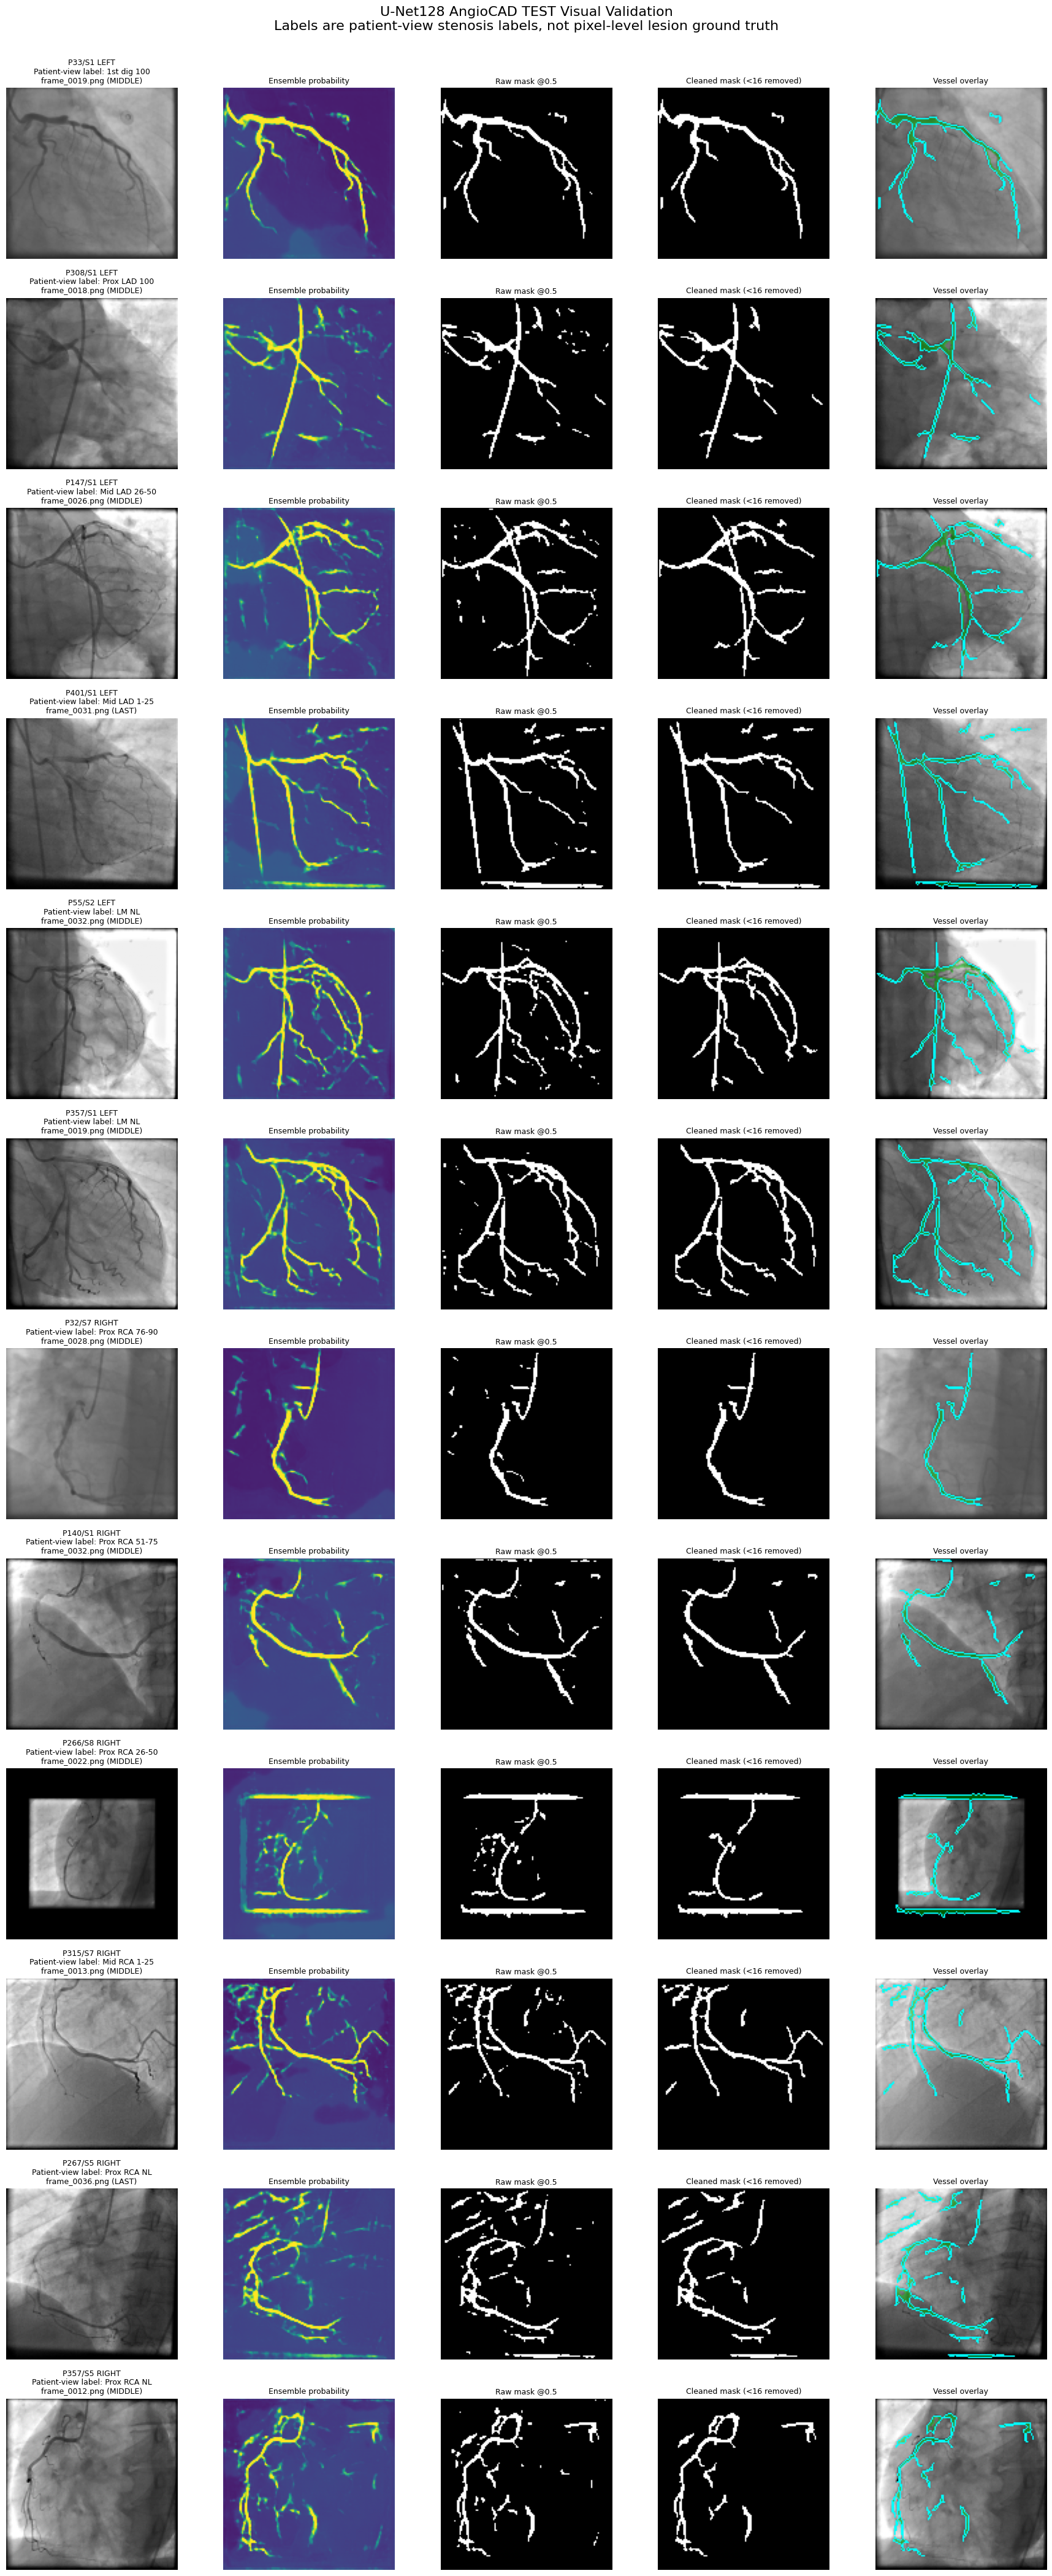


✅ AngioCAD U-Net128 시각검증 출력 완료
대표 series: 12
후보 프레임: 36
Overlay: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/08_angiocad_unet128_visual_overlay.png
Review template: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/09_angiocad_unet128_visual_review.csv
Predictions: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet128_angiocad_visual_validation/07_angiocad_unet128_visual_predictions.npz


In [ ]:
#@title 04-05. AngioCAD TEST 표본 선정부터 U-Net128 시각화까지 한 번에 실행

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert (
    "unet128_ensemble" in globals()
    and len(unet128_ensemble) == 5
), "U-Net128 5-Fold ensemble이 필요합니다."

# 압축 해제된 원본 경로 복구
if "ANGIOCAD_ROOT" not in globals():
    ANGIOCAD_ROOT = Path(
        "/content/AngioCAD/AngioCAD_Dataset"
    )

ANGIOCAD_ROOT = Path(ANGIOCAD_ROOT)

assert ANGIOCAD_ROOT.is_dir(), (
    f"AngioCAD 원본 폴더 없음: {ANGIOCAD_ROOT}"
)

frame_manifest_df = pd.read_csv(
    MANIFEST_PATH
)
clinical_df = pd.read_csv(
    CLINICAL_PATH
)
split_df = pd.read_csv(
    SPLIT_PATH
)

for df in [
    frame_manifest_df,
    clinical_df,
    split_df,
]:
    df.columns = [
        column.strip()
        if isinstance(column, str)
        else column
        for column in df.columns
    ]


def detect_id_column(df):
    for column in ["patient_id", "ID", "id"]:
        if column in df.columns:
            return column

    raise KeyError("patient ID 열 없음")


clinical_id_column = detect_id_column(
    clinical_df
)
split_id_column = detect_id_column(
    split_df
)

frame_manifest_df["patient_id"] = pd.to_numeric(
    frame_manifest_df["patient_id"],
    errors="raise",
).astype(int)

frame_manifest_df["series_id"] = pd.to_numeric(
    frame_manifest_df["series_id"],
    errors="raise",
).astype(int)

clinical_df["patient_id"] = pd.to_numeric(
    clinical_df[clinical_id_column],
    errors="raise",
).astype(int)

split_df["patient_id"] = pd.to_numeric(
    split_df[split_id_column],
    errors="raise",
).astype(int)

frame_manifest_df["view"] = (
    frame_manifest_df["view"]
    .astype(str)
    .str.strip()
    .str.upper()
)

LEFT_SEGMENTS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
]

RIGHT_SEGMENTS = [
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

GRADE_ORDER = {
    "NL": 0,
    "1-25": 1,
    "26-50": 2,
    "51-75": 3,
    "76-90": 4,
    "91-99": 5,
    "100": 6,
}

GRADE_LABEL = {
    value: key
    for key, value in GRADE_ORDER.items()
}


def normalize_grade(value):
    if pd.isna(value):
        return -1

    text = (
        str(value)
        .strip()
        .upper()
        .replace("–", "-")
        .replace("—", "-")
    )

    if text in {"NORMAL", "0", "0.0"}:
        text = "NL"

    if text.endswith(".0"):
        text = text[:-2]

    return GRADE_ORDER.get(text, -1)


def get_view_target(row, view):
    segments = (
        LEFT_SEGMENTS
        if view == "LEFT"
        else RIGHT_SEGMENTS
    )

    results = []

    for segment in segments:
        if segment not in row.index:
            continue

        grade = normalize_grade(
            row[segment]
        )

        if grade >= 0:
            results.append(
                (segment, grade)
            )

    if not results:
        return {
            "max_segment": None,
            "max_grade_index": -1,
            "max_grade_label": "MISSING",
        }

    segment, grade = max(
        results,
        key=lambda item: item[1],
    )

    return {
        "max_segment": segment,
        "max_grade_index": grade,
        "max_grade_label": GRADE_LABEL[grade],
    }


view_target_rows = []

for _, row in clinical_df.iterrows():
    for view in ["LEFT", "RIGHT"]:
        view_target_rows.append({
            "patient_id": int(
                row["patient_id"]
            ),
            "view": view,
            **get_view_target(row, view),
        })

view_target_df = pd.DataFrame(
    view_target_rows
)


def severity_group(grade):
    if grade == 0:
        return "NORMAL"

    if grade in {1, 2}:
        return "LE_50"

    if grade >= 3:
        return "GT_50"

    return "MISSING"


view_target_df["severity_group"] = (
    view_target_df["max_grade_index"]
    .map(severity_group)
)

test_patient_ids = set(
    split_df.loc[
        split_df["final_split"]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TEST"),
        "patient_id",
    ]
)

test_manifest_df = (
    frame_manifest_df
    .loc[
        frame_manifest_df["patient_id"]
        .isin(test_patient_ids)
    ]
    .merge(
        view_target_df,
        on=["patient_id", "view"],
        how="left",
        validate="many_to_one",
    )
)

# TEST × LEFT/RIGHT × 정상/≤50%/>50%에서 각 2 series
test_series_df = (
    test_manifest_df[
        [
            "patient_id",
            "series_id",
            "view",
            "max_segment",
            "max_grade_index",
            "max_grade_label",
            "severity_group",
        ]
    ]
    .drop_duplicates(
        ["patient_id", "series_id"]
    )
    .loc[
        lambda df:
        df["severity_group"].isin([
            "NORMAL",
            "LE_50",
            "GT_50",
        ])
    ]
    .reset_index(drop=True)
)

rng = np.random.default_rng(42)
sampled_groups = []

for (
    view,
    severity,
), group_df in test_series_df.groupby(
    ["view", "severity_group"],
    sort=True,
):
    candidates = (
        group_df
        .sort_values(
            ["patient_id", "series_id"]
        )
        .drop_duplicates("patient_id")
        .reset_index(drop=True)
    )

    sample_count = min(
        2,
        len(candidates),
    )

    indices = rng.choice(
        len(candidates),
        size=sample_count,
        replace=False,
    )

    sampled_groups.append(
        candidates.iloc[indices]
    )

visual_series_df = (
    pd.concat(
        sampled_groups,
        ignore_index=True,
    )
    .sort_values([
        "view",
        "severity_group",
        "patient_id",
    ])
    .reset_index(drop=True)
)

assert len(visual_series_df) == 12

# 선택된 series의 프레임
selected_manifest_df = (
    test_manifest_df
    .merge(
        visual_series_df[
            ["patient_id", "series_id"]
        ],
        on=["patient_id", "series_id"],
        how="inner",
        validate="many_to_one",
    )
)

selected_manifest_df[
    "_frame_order"
] = (
    selected_manifest_df["frame_name"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(int)
)


def first_middle_last(group_df):
    group_df = (
        group_df
        .sort_values("_frame_order")
        .reset_index(drop=True)
    )

    positions = sorted(set([
        0,
        len(group_df) // 2,
        len(group_df) - 1,
    ]))

    position_names = []

    for position in positions:
        if position == 0:
            position_names.append("FIRST")
        elif position == len(group_df) - 1:
            position_names.append("LAST")
        else:
            position_names.append("MIDDLE")

    selected = group_df.iloc[
        positions
    ].copy()

    selected[
        "sample_position"
    ] = position_names

    return selected


candidate_groups = []

for _, group_df in (
    selected_manifest_df.groupby(
        ["patient_id", "series_id"],
        sort=True,
    )
):
    candidate_groups.append(
        first_middle_last(group_df)
    )

candidate_df = (
    pd.concat(
        candidate_groups,
        ignore_index=True,
    )
    .drop(columns=["_frame_order"])
)

candidate_df["resolved_frame_path"] = (
    candidate_df.apply(
        lambda row:
        str(
            ANGIOCAD_ROOT
            / str(int(row["patient_id"]))
            / str(int(row["series_id"]))
            / str(row["frame_name"])
        ),
        axis=1,
    )
)

candidate_df["file_exists"] = (
    candidate_df["resolved_frame_path"]
    .map(lambda value: Path(value).is_file())
)

assert len(candidate_df) == 36
assert candidate_df["file_exists"].all()

print("시각검증 series:", len(visual_series_df))
print("후보 프레임:", len(candidate_df))
print("실제 존재:", int(candidate_df["file_exists"].sum()))

# 이미지 로드 및 U-Net 입력 전처리
input_images = []
original_images = []

for path in candidate_df[
    "resolved_frame_path"
]:
    image = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE,
    )

    assert image is not None, (
        f"이미지 읽기 실패: {path}"
    )

    resized = cv2.resize(
        image,
        (128, 128),
        interpolation=cv2.INTER_AREA,
    )

    original_images.append(resized)
    input_images.append(
        resized.astype(np.float32) / 255.0
    )

original_images = np.stack(
    original_images
)

input_array = np.stack(
    input_images
)

input_tensor = torch.from_numpy(
    input_array[:, None, :, :]
).to(DEVICE)

# 5-Fold ensemble inference
fold_probabilities = []

with torch.no_grad():
    for fold, model in enumerate(
        unet128_ensemble
    ):
        probability = torch.sigmoid(
            model(input_tensor)
        )[:, 0]

        fold_probabilities.append(
            probability
            .detach()
            .cpu()
            .numpy()
        )

fold_probabilities = np.stack(
    fold_probabilities
)

ensemble_probabilities = (
    fold_probabilities.mean(axis=0)
)

ensemble_uncertainties = (
    fold_probabilities.std(axis=0)
)


def remove_small_components(
    binary_mask,
    minimum_size=16,
):
    binary_mask = (
        binary_mask.astype(np.uint8)
    )

    component_count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8,
        )
    )

    cleaned = np.zeros_like(
        binary_mask
    )

    retained_components = 0

    for component in range(
        1,
        component_count,
    ):
        area = stats[
            component,
            cv2.CC_STAT_AREA,
        ]

        if area >= minimum_size:
            cleaned[
                labels == component
            ] = 1

            retained_components += 1

    return cleaned, retained_components


raw_masks = (
    ensemble_probabilities >= 0.5
).astype(np.uint8)

cleaned_masks = []
retained_component_counts = []

for raw_mask in raw_masks:
    cleaned, component_count = (
        remove_small_components(
            raw_mask,
            minimum_size=16,
        )
    )

    cleaned_masks.append(cleaned)
    retained_component_counts.append(
        component_count
    )

cleaned_masks = np.stack(
    cleaned_masks
)

candidate_df[
    "raw_vessel_rate"
] = raw_masks.mean(axis=(1, 2))

candidate_df[
    "cleaned_vessel_rate"
] = cleaned_masks.mean(axis=(1, 2))

candidate_df[
    "removed_pixel_count"
] = (
    raw_masks.sum(axis=(1, 2))
    - cleaned_masks.sum(axis=(1, 2))
)

candidate_df[
    "retained_component_count"
] = retained_component_counts

candidate_df[
    "mean_ensemble_uncertainty"
] = ensemble_uncertainties.mean(
    axis=(1, 2)
)

candidate_df[
    "cleaned_probability_mass"
] = (
    ensemble_probabilities
    * cleaned_masks
).mean(axis=(1, 2))

# 각 series에서 혈관 신호가 가장 강한 대표 프레임 선택
representative_indices = (
    candidate_df.groupby(
        ["patient_id", "series_id"],
        sort=True,
    )["cleaned_probability_mass"]
    .idxmax()
    .to_numpy()
)

representative_df = (
    candidate_df.loc[
        representative_indices
    ]
    .sort_values([
        "view",
        "severity_group",
        "patient_id",
    ])
    .reset_index()
    .rename(
        columns={"index": "array_index"}
    )
)

assert len(representative_df) == 12

# 전체 추론 결과 저장
CANDIDATE_AUDIT_PATH = (
    VISUAL_DIR
    / "05_angiocad_unet128_candidate_inference.csv"
)

REPRESENTATIVE_PATH = (
    VISUAL_DIR
    / "06_angiocad_unet128_representative_frames.csv"
)

NPZ_PATH = (
    VISUAL_DIR
    / "07_angiocad_unet128_visual_predictions.npz"
)

candidate_df.to_csv(
    CANDIDATE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

representative_df.to_csv(
    REPRESENTATIVE_PATH,
    index=False,
    encoding="utf-8-sig",
)

np.savez_compressed(
    NPZ_PATH,
    images_uint8=original_images,
    probabilities_float16=(
        ensemble_probabilities.astype(
            np.float16
        )
    ),
    uncertainty_float16=(
        ensemble_uncertainties.astype(
            np.float16
        )
    ),
    raw_masks_uint8=raw_masks,
    cleaned_masks_uint8=cleaned_masks,
)

# 시각화
figure, axes = plt.subplots(
    nrows=12,
    ncols=5,
    figsize=(18, 42),
)

for row_index, row in (
    representative_df.iterrows()
):
    array_index = int(
        row["array_index"]
    )

    image = original_images[
        array_index
    ]

    probability = ensemble_probabilities[
        array_index
    ]

    raw_mask = raw_masks[
        array_index
    ]

    cleaned_mask = cleaned_masks[
        array_index
    ]

    overlay = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB,
    ).astype(np.float32)

    green = np.zeros_like(overlay)
    green[..., 1] = 255

    mask_boolean = cleaned_mask.astype(bool)

    overlay[mask_boolean] = (
        0.65 * overlay[mask_boolean]
        + 0.35 * green[mask_boolean]
    )

    overlay = np.clip(
        overlay,
        0,
        255,
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        cleaned_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    cv2.drawContours(
        overlay,
        contours,
        contourIdx=-1,
        color=(0, 255, 255),
        thickness=1,
    )

    title = (
        f"P{int(row['patient_id'])}"
        f"/S{int(row['series_id'])} "
        f"{row['view']}\n"
        f"Patient-view label: "
        f"{row['max_segment']} "
        f"{row['max_grade_label']}\n"
        f"{row['frame_name']} "
        f"({row['sample_position']})"
    )

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[row_index, 0].set_title(
        title,
        fontsize=9,
    )

    axes[row_index, 1].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 1].set_title(
        "Ensemble probability",
        fontsize=9,
    )

    axes[row_index, 2].imshow(
        raw_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 2].set_title(
        "Raw mask @0.5",
        fontsize=9,
    )

    axes[row_index, 3].imshow(
        cleaned_mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 3].set_title(
        "Cleaned mask (<16 removed)",
        fontsize=9,
    )

    axes[row_index, 4].imshow(
        overlay
    )
    axes[row_index, 4].set_title(
        "Vessel overlay",
        fontsize=9,
    )

    for column in range(5):
        axes[row_index, column].axis(
            "off"
        )

figure.suptitle(
    "U-Net128 AngioCAD TEST Visual Validation\n"
    "Labels are patient-view stenosis labels, "
    "not pixel-level lesion ground truth",
    fontsize=16,
    y=0.999,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.996]
)

OVERLAY_PATH = (
    VISUAL_DIR
    / "08_angiocad_unet128_visual_overlay.png"
)

plt.savefig(
    OVERLAY_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

# 사람의 시각 검토용 빈 양식
review_df = representative_df[
    [
        "patient_id",
        "series_id",
        "view",
        "max_segment",
        "max_grade_label",
        "severity_group",
        "frame_name",
        "cleaned_vessel_rate",
        "mean_ensemble_uncertainty",
    ]
].copy()

review_df[
    "vessel_tree_coverage_0_to_2"
] = ""

review_df[
    "major_vessel_continuity_0_to_2"
] = ""

review_df[
    "narrowing_shape_preserved"
] = ""

review_df[
    "catheter_false_positive"
] = ""

review_df[
    "border_false_positive"
] = ""

review_df[
    "overall_segmentation_pass"
] = ""

review_df[
    "reviewer_note"
] = ""

REVIEW_PATH = (
    VISUAL_DIR
    / "09_angiocad_unet128_visual_review.csv"
)

review_df.to_csv(
    REVIEW_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ AngioCAD U-Net128 시각검증 출력 완료")
print("대표 series:", len(representative_df))
print("후보 프레임:", len(candidate_df))
print("Overlay:", OVERLAY_PATH)
print("Review template:", REVIEW_PATH)
print("Predictions:", NPZ_PATH)